In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Verify GPU is available
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
print('GPU:', result.stdout.strip() if result.returncode == 0 else 'Not available — will use CPU')

import subprocess
subprocess.run(['pip', 'install', 'seaborn', '-q'])
print('Ready.')

Mounted at /content/drive
GPU: Tesla T4, 15360 MiB
Ready.


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── PATHS ─────────────────────────────────────────────────────
PIE_PATH     = '/content/drive/MyDrive/PIE'
FEATURE_PATH = f'{PIE_PATH}/features'
MODEL_PATH   = f'{PIE_PATH}/models'
os.makedirs(MODEL_PATH, exist_ok=True)

# ── CONFIG ────────────────────────────────────────────────────
SEQ_LEN    = 30
N_FEATURES = 36
N_CLASSES  = 6
BATCH_SIZE = 32
EPOCHS     = 100    # EarlyStopping will stop before this
PATIENCE   = 15     # EarlyStopping patience
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── LABEL NAMES ───────────────────────────────────────────────
LABEL_NAMES = [
    'Waiting',     # 0
    'Hesitant',    # 1
    'Committed',   # 2
    'Distracted',  # 3
    'Aggressive',  # 4
    'Jaywalk'      # 5
]

print(f'\nFeature path : {FEATURE_PATH}')
print(f'Model path   : {MODEL_PATH}')

TensorFlow version : 2.20.0
GPU available      : True

Feature path : /content/drive/MyDrive/PIE/features
Model path   : /content/drive/MyDrive/PIE/models


In [3]:
X_train = np.load(f'{FEATURE_PATH}/X_train.npy')  # (2721, 30, 36)
y_train = np.load(f'{FEATURE_PATH}/y_train.npy')  # (2721,)
X_val   = np.load(f'{FEATURE_PATH}/X_val.npy')    # (583,  30, 36)
y_val   = np.load(f'{FEATURE_PATH}/y_val.npy')    # (583,)
X_test  = np.load(f'{FEATURE_PATH}/X_test.npy')   # (584,  30, 36)
y_test  = np.load(f'{FEATURE_PATH}/y_test.npy')   # (584,)

print('Data loaded:')
print(f'  X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}   y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}  y_test  : {y_test.shape}')
print(f'  dtype   : {X_train.dtype}')

# Verify no NaN
assert not np.isnan(X_train).any(), 'NaN found in X_train!'
assert not np.isnan(X_val).any(),   'NaN found in X_val!'
assert not np.isnan(X_test).any(),  'NaN found in X_test!'
print('\nNo NaN values detected. Data is clean.')

print('\nClass distribution in training set:')
for i, name in enumerate(LABEL_NAMES):
    n   = int(np.sum(y_train == i))
    pct = n / len(y_train) * 100
    bar = '█' * int(pct / 2)
    print(f'  {i} {name:<15} {n:>5,}  ({pct:5.1f}%)  {bar}')

Data loaded:
  X_train : (2721, 30, 36)  y_train : (2721,)
  X_val   : (583, 30, 36)   y_val   : (583,)
  X_test  : (584, 30, 36)  y_test  : (584,)
  dtype   : float32

No NaN values detected. Data is clean.

Class distribution in training set:
  0 Waiting         1,200  ( 44.1%)  ██████████████████████
  1 Hesitant          151  (  5.5%)  ██
  2 Committed         549  ( 20.2%)  ██████████
  3 Distracted        153  (  5.6%)  ██
  4 Aggressive        431  ( 15.8%)  ███████
  5 Jaywalk           237  (  8.7%)  ████


In [4]:
# Compute class weights from training labels
classes     = np.arange(N_CLASSES)
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = {i: float(w) for i, w in enumerate(raw_weights)}

print('Class weights (higher = model pays more attention to this class):')
for i, name in enumerate(LABEL_NAMES):
    n = int(np.sum(y_train == i))
    print(f'  {i} {name:<15}  n={n:>5,}  weight={class_weights[i]:.3f}')

Class weights (higher = model pays more attention to this class):
  0 Waiting          n=1,200  weight=0.378
  1 Hesitant         n=  151  weight=3.003
  2 Committed        n=  549  weight=0.826
  3 Distracted       n=  153  weight=2.964
  4 Aggressive       n=  431  weight=1.052
  5 Jaywalk          n=  237  weight=1.914


In [5]:
def build_lstm_model(seq_len=30, n_features=36, n_classes=6):
    """
    Two-layer LSTM for pedestrian mental state classification.

    Architecture (from proposal):
      Input  : (30, 36)  — 30-frame sequence, 36 features per frame
      LSTM   : 128 units, return_sequences=True
      Dropout: 0.3
      LSTM   : 64 units
      Dropout: 0.3
      Dense  : 6 units, softmax  — predicts one of 6 mental states
    """
    inputs = keras.Input(shape=(seq_len, n_features), name='sequence_input')

    # Layer 1: LSTM with 128 units
    x = layers.LSTM(
        128,
        return_sequences=True,   # pass full sequence to next LSTM
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='lstm_1'
    )(inputs)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    # Layer 2: LSTM with 64 units
    x = layers.LSTM(
        64,
        return_sequences=False,  # only final timestep output
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='lstm_2'
    )(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # Output: 6-class softmax
    outputs = layers.Dense(n_classes, activation='softmax', name='mental_state_output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='LSTM_MentalState')
    return model


model = build_lstm_model(SEQ_LEN, N_FEATURES, N_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

total_params = model.count_params()
print(f'\nTotal parameters : {total_params:,}')

Model: "LSTM_MentalState"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 30, 36)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mental_state_output (Dense)     │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,278 (524.52 KB)

 Trainable params: 134,278 (524.52 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters : 134,278


In [6]:
MODEL_SAVE_PATH = f'{MODEL_PATH}/lstm_mental_state_best.h5'

cb_list = [
    # Save best model based on validation loss
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # Stop training if val_loss doesn't improve for PATIENCE epochs
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when val_loss plateaus
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),

    # Log training history to CSV
    callbacks.CSVLogger(
        f'{MODEL_PATH}/training_log.csv',
        append=False
    )
]

print('Callbacks configured:')
print(f'  ModelCheckpoint  → {MODEL_SAVE_PATH}')
print(f'  EarlyStopping    patience={PATIENCE}')
print(f'  ReduceLROnPlateau factor=0.5, patience=7')
print(f'  CSVLogger        → {MODEL_PATH}/training_log.csv')

Callbacks configured:
  ModelCheckpoint  → /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
  EarlyStopping    patience=15
  ReduceLROnPlateau factor=0.5, patience=7
  CSVLogger        → /content/drive/MyDrive/PIE/models/training_log.csv


In [7]:
print('Starting training...')
print(f'  Input shape  : {X_train.shape}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Max epochs   : {EPOCHS}')
print(f'  Class weights: enabled')
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_list,
    verbose=1
)

print(f'\nTraining finished at epoch {len(history.history["loss"])}')
print(f'Best val_loss    : {min(history.history["val_loss"]):.4f}')
print(f'Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')

Starting training...
  Input shape  : (2721, 30, 36)
  Batch size   : 32
  Max epochs   : 100
  Class weights: enabled

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4963 - loss: 1.4703
Epoch 1: val_loss improved from None to 1.05497, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5432 - loss: 1.3222 - val_accuracy: 0.6449 - val_loss: 1.0550 - learning_rate: 0.0010
Epoch 2/100
84/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6161 - loss: 1.0796
Epoch 2: val_loss improved from 1.05497 to 0.96671, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6193 - loss: 1.0532 - val_accuracy: 0.6569 - val_loss: 0.9667 - learning_rate: 0.0010
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6647 - loss: 0.9396
Epoch 3: val_loss improved from 0.96671 to 0.87948, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6733 - loss: 0.8974 - val_accuracy: 0.6792 - val_loss: 0.8795 - learning_rate: 0.0010
Epoch 4/100
84/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6882 - loss: 0.8219
Epoch 4: val_loss improved from 0.87948 to 0.80237, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7005 - loss: 0.7934 - val_accuracy: 0.7238 - val_loss: 0.8024 - learning_rate: 0.0010
Epoch 5/100
83/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7499 - loss: 0.7093
Epoch 5: val_loss improved from 0.80237 to 0.77006, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7446 - loss: 0.6807 - val_accuracy: 0.7273 - val_loss: 0.7701 - learning_rate: 0.0010
Epoch 6/100
85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7859 - loss: 0.6087
Epoch 6: val_loss did not improve from 0.77006
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7729 - loss: 0.5964 - val_accuracy: 0.6998 - val_loss: 0.8201 - learning_rate: 0.0010
Epoch 7/100
85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7899 - loss: 0.5597
Epoch 7: val_loss improved from 0.77006 to 0.75616, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7927 - loss: 0.5385 - val_accuracy: 0.7358 - val_loss: 0.7562 - learning_rate: 0.0010
Epoch 8/100
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7776 - loss: 0.5490
Epoch 8: val_loss did not improve from 0.75616
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7630 - loss: 0.5550 - val_accuracy: 0.7290 - val_loss: 0.7909 - learning_rate: 0.0010
Epoch 9/100
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8177 - loss: 0.4662
Epoch 9: val_loss did not improve from 0.75616
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8133 - loss: 0.4578 - val_accuracy: 0.7530 - val_loss: 0.7591 - learning_rate: 0.0010
Epoch 10/100
82/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8526 - loss: 0.4164
Epoch 10: val_loss did not improve from 0.75616
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8276 - loss: 0.4170 - val_accurac


Epoch 11: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8486 - loss: 0.3759 - val_accuracy: 0.7581 - val_loss: 0.7284 - learning_rate: 0.0010
Epoch 12/100
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8682 - loss: 0.3789
Epoch 12: val_loss did not improve from 0.72844
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8493 - loss: 0.3764 - val_accuracy: 0.7479 - val_loss: 0.7287 - learning_rate: 0.0010
Epoch 13/100
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8678 - loss: 0.3304
Epoch 13: val_loss improved from 0.72844 to 0.71750, saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5



Epoch 13: finished saving model to /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8585 - loss: 0.3247 - val_accuracy: 0.7667 - val_loss: 0.7175 - learning_rate: 0.0010
Epoch 14/100
82/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8982 - loss: 0.2803
Epoch 14: val_loss did not improve from 0.71750
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8750 - loss: 0.2982 - val_accuracy: 0.7684 - val_loss: 0.8010 - learning_rate: 0.0010
Epoch 15/100
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8918 - loss: 0.3037
Epoch 15: val_loss did not improve from 0.71750
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8758 - loss: 0.2960 - val_accuracy: 0.7410 - val_loss: 0.7984 - learning_rate: 0.0010
Epoch 16/100
82/86 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8937 - loss: 0.2574
Epoch 16: val_loss did not improve from 0.71750
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8868 - loss: 0.2575 - val_ac

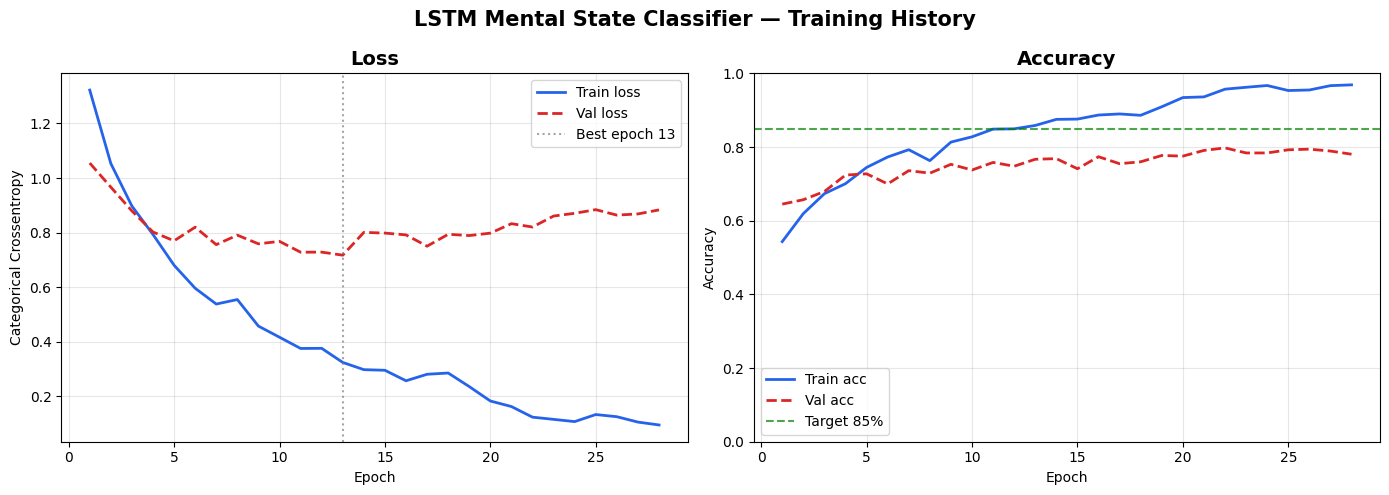

Saved: /content/drive/MyDrive/PIE/models/training_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['loss']) + 1)

# ── Loss ──────────────────────────────────────────────────────
axes[0].plot(epochs_ran, history.history['loss'],     label='Train loss',  color='#2563EB', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val loss',    color='#DC2626', linewidth=2, linestyle='--')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mark best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Best epoch {best_epoch}')
axes[0].legend()

# ── Accuracy ──────────────────────────────────────────────────
axes[1].plot(epochs_ran, history.history['accuracy'],     label='Train acc',  color='#2563EB', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Val acc',    color='#DC2626', linewidth=2, linestyle='--')
axes[1].axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='Target 85%')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Mental State Classifier — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {MODEL_PATH}/training_curves.png')

In [9]:
# Load best saved model
best_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f'Loaded best model from: {MODEL_SAVE_PATH}')

# Predict on test set
y_prob = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)  # (N, 6)
y_pred = np.argmax(y_prob, axis=1)                                      # (N,)

# Overall metrics
test_acc  = accuracy_score(y_test, y_pred)
macro_f1  = f1_score(y_test, y_pred, average='macro',    zero_division=0)
weight_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print()
print('=' * 55)
print('TEST SET RESULTS')
print('=' * 55)
print(f'  Overall Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  Macro F1 Score   : {macro_f1:.4f}  ({macro_f1*100:.1f}%)')
print(f'  Weighted F1 Score: {weight_f1:.4f}  ({weight_f1*100:.1f}%)')
print()

# Check against proposal targets
acc_ok = '✅ PASS' if test_acc  >= 0.85 else '❌ BELOW TARGET'
f1_ok  = '✅ PASS' if macro_f1  >= 0.80 else '❌ BELOW TARGET'
print(f'  Target accuracy > 85% : {acc_ok}  ({test_acc*100:.1f}%)')
print(f'  Target macro F1 > 80% : {f1_ok}   ({macro_f1*100:.1f}%)')

Loaded best model from: /content/drive/MyDrive/PIE/models/lstm_mental_state_best.h5

TEST SET RESULTS
  Overall Accuracy : 0.7705  (77.1%)
  Macro F1 Score   : 0.6968  (69.7%)
  Weighted F1 Score: 0.7719  (77.2%)

  Target accuracy > 85% : ❌ BELOW TARGET  (77.1%)
  Target macro F1 > 80% : ❌ BELOW TARGET   (69.7%)


In [10]:
print('Per-class Classification Report:')
print()
report = classification_report(
    y_test, y_pred,
    target_names=LABEL_NAMES,
    zero_division=0
)
print(report)

# Save report to file
report_dict = classification_report(
    y_test, y_pred,
    target_names=LABEL_NAMES,
    zero_division=0,
    output_dict=True
)
with open(f'{MODEL_PATH}/classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)
print(f'Saved: {MODEL_PATH}/classification_report.json')

Per-class Classification Report:

              precision    recall  f1-score   support

     Waiting       0.84      0.78      0.81       257
    Hesitant       0.44      0.55      0.49        33
   Committed       0.81      0.89      0.85       118
  Distracted       0.57      0.75      0.65        32
  Aggressive       0.84      0.82      0.83        93
     Jaywalk       0.62      0.51      0.56        51

    accuracy                           0.77       584
   macro avg       0.69      0.72      0.70       584
weighted avg       0.78      0.77      0.77       584

Saved: /content/drive/MyDrive/PIE/models/classification_report.json


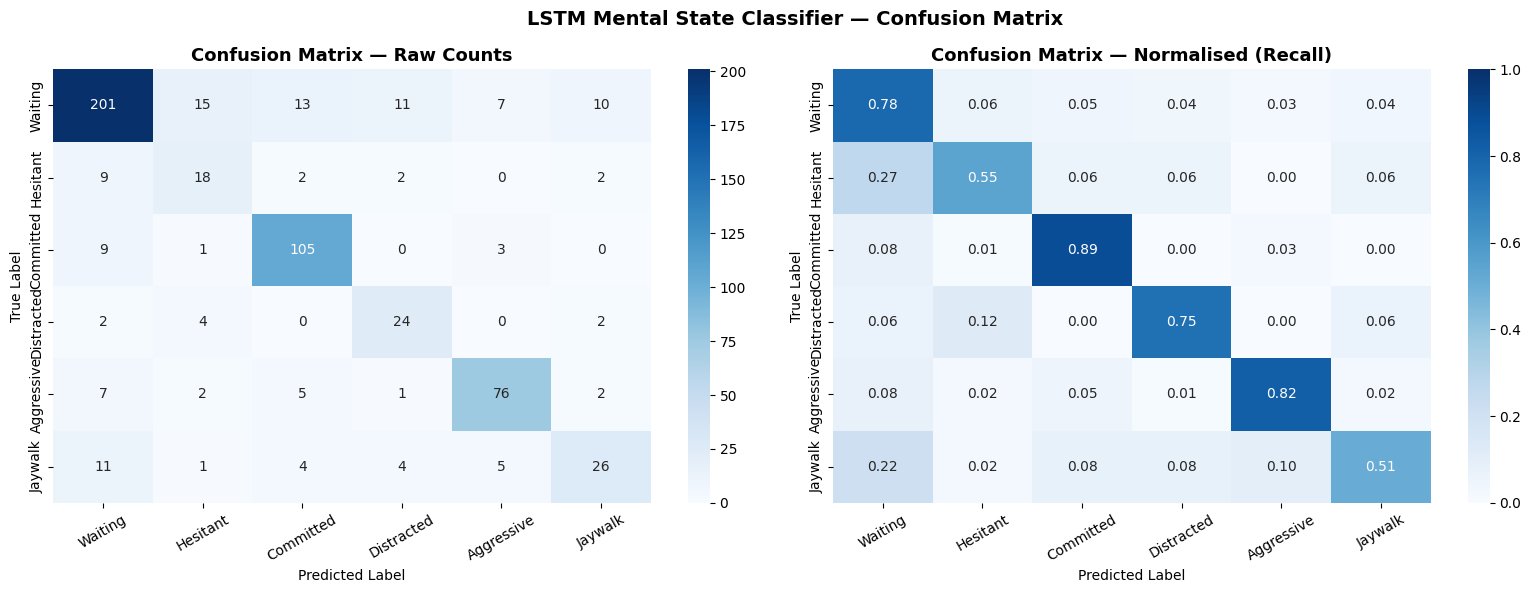

Saved: /content/drive/MyDrive/PIE/models/confusion_matrix.png


In [11]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)

# Normalised (per-class recall)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    cmap='Blues', vmin=0, vmax=1, ax=axes[1]
)
axes[1].set_title('Confusion Matrix — Normalised (Recall)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('LSTM Mental State Classifier — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {MODEL_PATH}/confusion_matrix.png')

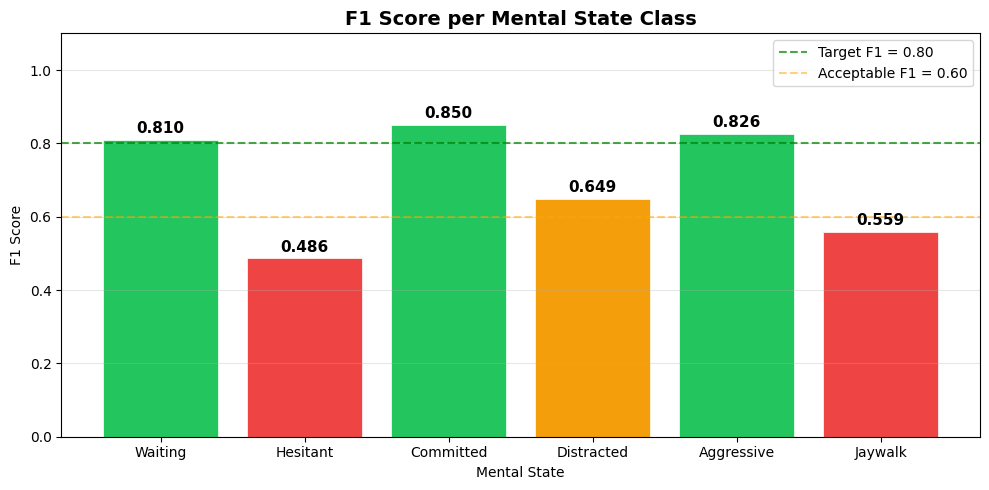

Per-class F1 scores:
  ✅ Waiting          F1 = 0.8105
  ❌ Hesitant         F1 = 0.4865
  ✅ Committed        F1 = 0.8502
  ⚠️ Distracted       F1 = 0.6486
  ✅ Aggressive       F1 = 0.8261
  ❌ Jaywalk          F1 = 0.5591


In [12]:
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

colors = ['#22C55E' if f >= 0.80 else '#F59E0B' if f >= 0.60 else '#EF4444'
          for f in per_class_f1]

plt.figure(figsize=(10, 5))
bars = plt.bar(LABEL_NAMES, per_class_f1, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(y=0.80, color='green',  linestyle='--', alpha=0.7, label='Target F1 = 0.80')
plt.axhline(y=0.60, color='orange', linestyle='--', alpha=0.5, label='Acceptable F1 = 0.60')

for bar, f1 in zip(bars, per_class_f1):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{f1:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('F1 Score per Mental State Class', fontsize=14, fontweight='bold')
plt.xlabel('Mental State')
plt.ylabel('F1 Score')
plt.ylim([0, 1.1])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class F1 scores:')
for name, f1 in zip(LABEL_NAMES, per_class_f1):
    status = '✅' if f1 >= 0.80 else '⚠️' if f1 >= 0.60 else '❌'
    print(f'  {status} {name:<15}  F1 = {f1:.4f}')

In [13]:
best_model.save(f'{MODEL_PATH}/lstm_mental_state_best.h5')
best_model.export(f'{MODEL_PATH}/lstm_mental_state_saved')

# Save training summary JSON
summary = {
    'architecture': {
        'input_shape':  [SEQ_LEN, N_FEATURES],
        'lstm_1_units': 128,
        'dropout_1':    0.3,
        'lstm_2_units': 64,
        'dropout_2':    0.3,
        'output_units': N_CLASSES,
        'activation':   'softmax',
        'total_params': int(best_model.count_params())
    },
    'training': {
        'epochs_run':    len(history.history['loss']),
        'batch_size':    BATCH_SIZE,
        'optimizer':     'Adam',
        'learning_rate': 1e-3,
        'loss':          'sparse_categorical_crossentropy',
        'class_weights': class_weights,
        'best_val_loss': float(min(history.history['val_loss'])),
        'best_val_acc':  float(max(history.history['val_accuracy']))
    },
    'test_results': {
        'accuracy':   float(test_acc),
        'macro_f1':   float(macro_f1),
        'weighted_f1': float(weight_f1),
        'per_class_f1': {name: float(f1) for name, f1 in zip(LABEL_NAMES, per_class_f1)}
    },
    'targets_met': {
        'accuracy_85pct': bool(test_acc  >= 0.85),
        'macro_f1_80pct': bool(macro_f1  >= 0.80)
    },
    'label_names': LABEL_NAMES
}

with open(f'{MODEL_PATH}/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 55)
print('TRAINING COMPLETE — FINAL SUMMARY')
print('=' * 55)
print(f'  Epochs run       : {summary["training"]["epochs_run"]}')
print(f'  Best val acc     : {summary["training"]["best_val_acc"]*100:.1f}%')
print(f'  Test accuracy    : {test_acc*100:.1f}%  (target >85%)')
print(f'  Test macro F1    : {macro_f1*100:.1f}%  (target >80%)')
print()
print('Saved files:')
for fname in [
    'lstm_mental_state_best.h5',
    'training_curves.png',
    'confusion_matrix.png',
    'per_class_f1.png',
    'classification_report.json',
    'training_summary.json',
    'training_log.csv'
]:
    fp = f'{MODEL_PATH}/{fname}'
    exists = os.path.exists(fp)
    size   = f'{os.path.getsize(fp)/1024:.0f} KB' if exists else ''
    print(f'  {"✅" if exists else "❌"} {fname:<40} {size}')

Saved artifact at '/content/drive/MyDrive/PIE/models/lstm_mental_state_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 36), dtype=tf.float32, name='sequence_input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135590212760976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212759440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212759248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212747344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212755792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212762320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212758672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135590212761936: TensorSpec(shape=(), dtype=tf.resource, name=None)
TRAINING COMPLETE — FINAL SUMMARY
  Epochs run       : 28
  Best val acc     : 79.8%
  Test accuracy    : 77.1%  (targ